In [3]:
from sshtunnel import SSHTunnelForwarder

with SSHTunnelForwarder(
    ("13.239.79.237", 22),
    ssh_username="ubuntu",
    ssh_pkey="C:/Sagar/Futsal_ML/Futsal-ML-Analysis/Futsal_Match_Prediction_Womens/db_pass/FutsalozApp_ProdNew.pem",
    remote_bind_address=(
        "futsalozdb.ce8imxcnx4zv.ap-southeast-2.rds.amazonaws.com",
        3306
    )
) as tunnel:

    print("SSH Tunnel Connected")
    print("Local Port:", tunnel.local_bind_port)

SSH Tunnel Connected
Local Port: 64769


In [4]:
import pandas as pd
from sqlalchemy import create_engine, text
from sshtunnel import SSHTunnelForwarder

SSH_HOST = "13.239.79.237"
SSH_PORT = 22
SSH_USER = "ubuntu"
SSH_KEY = "C:/Sagar/Futsal_ML/Futsal-ML-Analysis/Futsal_Match_Prediction_Womens/db_pass/FutsalozApp_ProdNew.pem"

MYSQL_HOST = "futsalozdb.ce8imxcnx4zv.ap-southeast-2.rds.amazonaws.com"
MYSQL_PORT = 3306
MYSQL_USER = "admin"
MYSQL_PASSWORD = "Dk2poYagiSAUu04wEBtH"
MYSQL_DATABASE = "futsaloz"

with SSHTunnelForwarder(
    (SSH_HOST, SSH_PORT),
    ssh_username=SSH_USER,
    ssh_pkey=SSH_KEY,
    remote_bind_address=(MYSQL_HOST, MYSQL_PORT)
) as tunnel:

    engine = create_engine(
        f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}"
        f"@127.0.0.1:{tunnel.local_bind_port}/{MYSQL_DATABASE}"
    )

    query="""
    SELECT
    lmsc.*,
    u.first_name,
    u.last_name,
    u.date_of_birth
FROM futsaloz.live_match_score_cards lmsc
LEFT JOIN futsaloz.users u
    ON lmsc.user_id = u.user_id
WHERE lmsc.comp_id IN (
    155, 239, 325, 447, 532,
	633, 724, 879, 945, 1025, 1083
)
AND lmsc.type IN (
    'SCORE',
    'FOULS',
    'YELLOWCARD',
    'REDCARD'
)
AND lmsc.user_id <> 3;"""

    with engine.connect() as conn:
        result = conn.execute(text(query))
        player_raw = pd.DataFrame(result.fetchall(), columns=result.keys())
    
player_raw


,id,match_id,comp_id,team_id,user_id,assist_player_id,type,is_self_goal,time,timer_type,half,match_time,is_goal,is_reset,created_on,updated_on,first_name,last_name,date_of_birth
0,50561,42222,155,29,672,NaN,SCORE,0,08:58,PLAY,1,08:58,1,0,2021-05-05 16:44:05,2021-05-05 16:44:05,Alyson,Pym,1994-10-27
1,50572,42222,155,29,655,NaN,SCORE,0,06:09,PLAY,1,06:09,1,0,2021-05-05 16:48:26,2021-05-05 16:48:26,Rebecca,Davies,1992-11-20
2,50573,42222,155,25,668,NaN,FOULS,0,05:19,PLAY,1,05:19,0,0,2021-05-05 16:49:15,2021-05-05 16:49:15,Megan,Grove,2002-11-09
3,50588,42222,155,29,1774,NaN,SCORE,0,19:35,PLAY,2,19:35,1,0,2021-05-05 16:58:58,2021-05-05 16:58:58,Eva,Jan,2001-07-11
4,50591,42222,155,25,3001,NaN,FOULS,0,18:09,PLAY,2,18:09,0,0,2021-05-05 17:00:24,2021-05-05 17:00:24,Melanie,Elasmar,2000-09-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10140,1576951,253960,1025,3487,24097,0.0,FOULS,0,19:02,PLAY,2,19:02,0,0,2026-06-26 17:39:59,2026-06-26 17:39:59,Stella,Nissan,2005-06-23
10141,1577010,253960,1025,3487,21162,0.0,FOULS,0,12:23,PLAY,2,12:23,0,0,2026-06-26 17:51:57,2026-06-26 17:51:57,Brianna,Stellas,2002-11-19
10142,1577059,253960,1025,3487,31685,0.0,FOULS,0,07:11,PLAY,2,07:11,0,0,2026-06-26 18:01:59,2026-06-26 18:01:59,Jade,Curci,2006-11-09
10143,1577094,253960,1025,3487,21162,NaN,SCORE,0,04:14,PLAY,2,04:14,1,0,2026-06-26 18:07:55,2026-06-28 08:52:27,Brianna,Stellas,2002-11-19


In [208]:
# import pandas as pd
# from sqlalchemy import create_engine
# from sshtunnel import SSHTunnelForwarder

# SSH_HOST = "13.239.79.237"
# SSH_PORT = 22
# SSH_USER = "ubuntu"
# SSH_KEY = "C:/Sagar/Futsal_ML/Futsal-ML-Analysis/Futsal_Match_Prediction_Womens/db_pass/FutsalozApp_ProdNew.pem"

# MYSQL_HOST = "futsalozdb.ce8imxcnx4zv.ap-southeast-2.rds.amazonaws.com"
# MYSQL_PORT = 3306
# MYSQL_USER = "admin"
# MYSQL_PASSWORD = "Dk2poYagiSAUu04wEBtH"
# MYSQL_DATABASE = "futsaloz"

# with SSHTunnelForwarder(
#     (SSH_HOST, SSH_PORT),
#     ssh_username=SSH_USER,
#     ssh_pkey=SSH_KEY,
#     remote_bind_address=(MYSQL_HOST, MYSQL_PORT)
# ) as tunnel:

#     engine = create_engine(
#         f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}"
#         f"@127.0.0.1:{tunnel.local_bind_port}/{MYSQL_DATABASE}"
#     )

# #     query = """
# #     SELECT lmsc.*,
# #     u.first_name,
# #     u.last_name,
# #     u.date_of_birth
# # FROM futsaloz.live_match_score_cards lmsc
# # LEFT JOIN futsaloz.users u
# #     ON lmsc.user_id = u.user_id;
# #     """

#     query="""
#     SELECT
#     lmsc.*,
#     u.first_name,
#     u.last_name,
#     u.date_of_birth
# FROM futsaloz.live_match_score_cards lmsc
# LEFT JOIN futsaloz.users u
#     ON lmsc.user_id = u.user_id
# WHERE lmsc.comp_id IN (
#     155, 239, 325, 447, 532,
# 	633, 724, 879, 945, 1025, 1083
# )
# AND lmsc.type IN (
#     'SCORE',
#     'FOULS',
#     'YELLOWCARD',
#     'REDCARD'
# )
# AND lmsc.user_id <> 3;"""

#     player_raw = pd.read_sql(query, engine)
    
# player_raw

In [209]:
# import pandas as pd
# from sqlalchemy import create_engine
# from sshtunnel import SSHTunnelForwarder

# SSH_HOST = "13.239.79.237"
# SSH_PORT = 22
# SSH_USER = "ubuntu"
# SSH_KEY = "C:/Sagar/Futsal_ML/Futsal-ML-Analysis/Futsal_Match_Prediction/db_pass/FutsalozApp_ProdNew.pem"

# MYSQL_HOST = "futsalozdb.ce8imxcnx4zv.ap-southeast-2.rds.amazonaws.com"
# MYSQL_PORT = 3306
# MYSQL_USER = "admin"
# MYSQL_PASSWORD = "Dk2poYagiSAUu04wEBtH"
# MYSQL_DATABASE = "futsaloz"

# with SSHTunnelForwarder(
#     (SSH_HOST, SSH_PORT),
#     ssh_username=SSH_USER,
#     ssh_pkey=SSH_KEY,
#     remote_bind_address=(MYSQL_HOST, MYSQL_PORT)
# ) as tunnel:

#     engine = create_engine(
#         f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}"
#         f"@127.0.0.1:{tunnel.local_bind_port}/{MYSQL_DATABASE}"
#     )

#     query = """
# SELECT
#     m.*,
#     ht.name AS homeTeamName,
#     at.name AS awayTeamName,
#     c.name AS competitionName,
#     s.name AS seasonName
# FROM futsaloz.cmp_matches m
# LEFT JOIN futsaloz.teams ht
#     ON m.homeTeamId = ht.id
# LEFT JOIN futsaloz.teams at
#     ON m.awayTeamId = at.id
# LEFT JOIN futsaloz.competition c
#     ON m.cmp_id = c.id
# LEFT JOIN futsaloz.season s
#     ON c.season_id = s.id
# WHERE m.cmp_id IN (
#     1028, 948, 878, 725, 627,
#     527, 430, 312, 238, 130
# );
# """
#     matches_raw = pd.read_sql(query, engine)
    
# matches_raw

In [5]:
import pandas as pd
from sqlalchemy import create_engine, text  # Import 'text' from sqlalchemy
from sshtunnel import SSHTunnelForwarder

SSH_HOST = "13.239.79.237"
SSH_PORT = 22
SSH_USER = "ubuntu"
SSH_KEY = "C:/Sagar/Futsal_ML/Futsal-ML-Analysis/Futsal_Match_Prediction_Womens/db_pass/FutsalozApp_ProdNew.pem"

MYSQL_HOST = "futsalozdb.ce8imxcnx4zv.ap-southeast-2.rds.amazonaws.com"
MYSQL_PORT = 3306
MYSQL_USER = "admin"
MYSQL_PASSWORD = "Dk2poYagiSAUu04wEBtH"
MYSQL_DATABASE = "futsaloz"

with SSHTunnelForwarder(
    (SSH_HOST, SSH_PORT),
    ssh_username=SSH_USER,
    ssh_pkey=SSH_KEY,
    remote_bind_address=(MYSQL_HOST, MYSQL_PORT)
) as tunnel:

    engine = create_engine(
        f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}"
        f"@127.0.0.1:{tunnel.local_bind_port}/{MYSQL_DATABASE}"
    )

    query = """
    SELECT
    m.*,
    ht.name AS homeTeamName,
    at.name AS awayTeamName,
    c.name AS competitionName,
    s.name AS seasonName
FROM futsaloz.cmp_matches m
LEFT JOIN futsaloz.teams ht
    ON m.homeTeamId = ht.id
LEFT JOIN futsaloz.teams at
    ON m.awayTeamId = at.id
LEFT JOIN futsaloz.competition c
    ON m.cmp_id = c.id
LEFT JOIN futsaloz.season s
    ON c.season_id = s.id
WHERE m.cmp_id IN (
    155, 239, 325, 447, 532,
	633, 724, 879, 945, 1025, 1083
) and is_bye="false";
    """
    
    # 1. Connect using the engine context manager
    # 2. Wrap the query string in sqlalchemy.text()
    # 3. Load the result rows directly into pandas
    with engine.connect() as conn:
        result = conn.execute(text(query))
        matches_raw = pd.DataFrame(result.fetchall(), columns=result.keys())
    
matches_raw


,id,cmp_id,homeTeam,awayTeam,homeTeamId,awayTeamId,startTime,endTime,startDate,startingTime,...,is_bye,note,is_forfeited,is_cancel,homeTeamKits,awayTeamKits,homeTeamName,awayTeamName,competitionName,seasonName
0,42219,155,T3,T6,25,28,2021-04-28 21:00:00,2021-04-28 21:45:00,2021-04-28,21:00:00,...,false,None,false,no,0,0,Northern Phoenix FC Womens,FC Preston Womens,2021 Series Futsal Victoria Women,2021
1,42220,155,T1,T4,30,29,2021-04-28 21:45:00,2021-04-28 22:30:00,2021-04-28,21:45:00,...,false,None,false,no,0,0,Northcote City FC Women,FC Carlton Heart Womens,2021 Series Futsal Victoria Women,2021
2,42221,155,T2,T5,26,31,2021-04-28 22:30:00,2021-04-28 23:15:00,2021-04-28,22:30:00,...,false,None,false,no,0,0,Fitzroy FC Womens,Amazons FC,2021 Series Futsal Victoria Women,2021
3,42222,155,T3,T4,25,29,2021-05-05 21:00:00,2021-05-05 21:45:00,2021-05-05,21:00:00,...,false,None,false,no,0,0,Northern Phoenix FC Womens,FC Carlton Heart Womens,2021 Series Futsal Victoria Women,2021
4,42223,155,T1,T2,30,26,2021-05-05 21:45:00,2021-05-05 22:30:00,2021-05-05,21:45:00,...,false,None,false,no,0,0,Northcote City FC Women,Fitzroy FC Womens,2021 Series Futsal Victoria Women,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
751,267198,1083,T2,T3,26,3485,2026-11-27 19:40:00,2026-11-27 20:35:00,2026-11-27,19:40:00,...,false,None,false,no,0,0,Fitzroy FC Womens,Hume FC Women,2026.2 SERIES FUTSAL Premiership Women,2026.2
752,267199,1083,T1,T7,29,3487,2026-11-27 21:00:00,2026-11-27 21:55:00,2026-11-27,21:00:00,...,false,None,false,no,0,0,FC Carlton Heart Womens,Victoria Lions Womens,2026.2 SERIES FUTSAL Premiership Women,2026.2
753,267201,1083,T5,T7,3487,1845,2026-12-04 18:15:00,2026-12-04 19:10:00,2026-12-04,18:15:00,...,false,None,false,no,0,0,Victoria Lions Womens,Eastern One Nil FC Womens,2026.2 SERIES FUTSAL Premiership Women,2026.2
754,267202,1083,T1,T6,936,26,2026-12-04 19:40:00,2026-12-04 20:35:00,2026-12-04,19:40:00,...,false,None,false,no,0,0,Melbourne AKU FC Womens,Fitzroy FC Womens,2026.2 SERIES FUTSAL Premiership Women,2026.2


In [6]:
matches = matches_raw.copy()
matches

,id,cmp_id,homeTeam,awayTeam,homeTeamId,awayTeamId,startTime,endTime,startDate,startingTime,...,is_bye,note,is_forfeited,is_cancel,homeTeamKits,awayTeamKits,homeTeamName,awayTeamName,competitionName,seasonName
0,42219,155,T3,T6,25,28,2021-04-28 21:00:00,2021-04-28 21:45:00,2021-04-28,21:00:00,...,false,None,false,no,0,0,Northern Phoenix FC Womens,FC Preston Womens,2021 Series Futsal Victoria Women,2021
1,42220,155,T1,T4,30,29,2021-04-28 21:45:00,2021-04-28 22:30:00,2021-04-28,21:45:00,...,false,None,false,no,0,0,Northcote City FC Women,FC Carlton Heart Womens,2021 Series Futsal Victoria Women,2021
2,42221,155,T2,T5,26,31,2021-04-28 22:30:00,2021-04-28 23:15:00,2021-04-28,22:30:00,...,false,None,false,no,0,0,Fitzroy FC Womens,Amazons FC,2021 Series Futsal Victoria Women,2021
3,42222,155,T3,T4,25,29,2021-05-05 21:00:00,2021-05-05 21:45:00,2021-05-05,21:00:00,...,false,None,false,no,0,0,Northern Phoenix FC Womens,FC Carlton Heart Womens,2021 Series Futsal Victoria Women,2021
4,42223,155,T1,T2,30,26,2021-05-05 21:45:00,2021-05-05 22:30:00,2021-05-05,21:45:00,...,false,None,false,no,0,0,Northcote City FC Women,Fitzroy FC Womens,2021 Series Futsal Victoria Women,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
751,267198,1083,T2,T3,26,3485,2026-11-27 19:40:00,2026-11-27 20:35:00,2026-11-27,19:40:00,...,false,None,false,no,0,0,Fitzroy FC Womens,Hume FC Women,2026.2 SERIES FUTSAL Premiership Women,2026.2
752,267199,1083,T1,T7,29,3487,2026-11-27 21:00:00,2026-11-27 21:55:00,2026-11-27,21:00:00,...,false,None,false,no,0,0,FC Carlton Heart Womens,Victoria Lions Womens,2026.2 SERIES FUTSAL Premiership Women,2026.2
753,267201,1083,T5,T7,3487,1845,2026-12-04 18:15:00,2026-12-04 19:10:00,2026-12-04,18:15:00,...,false,None,false,no,0,0,Victoria Lions Womens,Eastern One Nil FC Womens,2026.2 SERIES FUTSAL Premiership Women,2026.2
754,267202,1083,T1,T6,936,26,2026-12-04 19:40:00,2026-12-04 20:35:00,2026-12-04,19:40:00,...,false,None,false,no,0,0,Melbourne AKU FC Womens,Fitzroy FC Womens,2026.2 SERIES FUTSAL Premiership Women,2026.2


In [8]:
matches.to_csv('matches.csv', index=False)

In [9]:
players = player_raw.copy()
players

,id,match_id,comp_id,team_id,user_id,assist_player_id,type,is_self_goal,time,timer_type,half,match_time,is_goal,is_reset,created_on,updated_on,first_name,last_name,date_of_birth
0,50561,42222,155,29,672,NaN,SCORE,0,08:58,PLAY,1,08:58,1,0,2021-05-05 16:44:05,2021-05-05 16:44:05,Alyson,Pym,1994-10-27
1,50572,42222,155,29,655,NaN,SCORE,0,06:09,PLAY,1,06:09,1,0,2021-05-05 16:48:26,2021-05-05 16:48:26,Rebecca,Davies,1992-11-20
2,50573,42222,155,25,668,NaN,FOULS,0,05:19,PLAY,1,05:19,0,0,2021-05-05 16:49:15,2021-05-05 16:49:15,Megan,Grove,2002-11-09
3,50588,42222,155,29,1774,NaN,SCORE,0,19:35,PLAY,2,19:35,1,0,2021-05-05 16:58:58,2021-05-05 16:58:58,Eva,Jan,2001-07-11
4,50591,42222,155,25,3001,NaN,FOULS,0,18:09,PLAY,2,18:09,0,0,2021-05-05 17:00:24,2021-05-05 17:00:24,Melanie,Elasmar,2000-09-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10140,1576951,253960,1025,3487,24097,0.0,FOULS,0,19:02,PLAY,2,19:02,0,0,2026-06-26 17:39:59,2026-06-26 17:39:59,Stella,Nissan,2005-06-23
10141,1577010,253960,1025,3487,21162,0.0,FOULS,0,12:23,PLAY,2,12:23,0,0,2026-06-26 17:51:57,2026-06-26 17:51:57,Brianna,Stellas,2002-11-19
10142,1577059,253960,1025,3487,31685,0.0,FOULS,0,07:11,PLAY,2,07:11,0,0,2026-06-26 18:01:59,2026-06-26 18:01:59,Jade,Curci,2006-11-09
10143,1577094,253960,1025,3487,21162,NaN,SCORE,0,04:14,PLAY,2,04:14,1,0,2026-06-26 18:07:55,2026-06-28 08:52:27,Brianna,Stellas,2002-11-19


In [10]:
players.to_csv('players.csv', index=False)

In [213]:
print("\nCOLUMNS")
print(players.columns)

print("\nDATA TYPES")
print(players.dtypes)

print("\nHEAD")
display(players.head())


COLUMNS
Index(['id', 'match_id', 'comp_id', 'team_id', 'user_id', 'assist_player_id',
       'type', 'is_self_goal', 'time', 'timer_type', 'half', 'match_time',
       'is_goal', 'is_reset', 'created_on', 'updated_on', 'first_name',
       'last_name', 'date_of_birth'],
      dtype='object')

DATA TYPES
id                           int64
match_id                     int64
comp_id                      int64
team_id                      int64
user_id                      int64
assist_player_id           float64
type                        object
is_self_goal                 int64
time                        object
timer_type                  object
half                         int64
match_time                  object
is_goal                     object
is_reset                    object
created_on          datetime64[ns]
updated_on          datetime64[ns]
first_name                  object
last_name                   object
date_of_birth               object
dtype: object

HEAD


,id,match_id,comp_id,team_id,user_id,assist_player_id,type,is_self_goal,time,timer_type,half,match_time,is_goal,is_reset,created_on,updated_on,first_name,last_name,date_of_birth
0,50561,42222,155,29,672,NaN,SCORE,0,08:58,PLAY,1,08:58,1,0,2021-05-05 16:44:05,2021-05-05 16:44:05,Alyson,Pym,1994-10-27
1,50572,42222,155,29,655,NaN,SCORE,0,06:09,PLAY,1,06:09,1,0,2021-05-05 16:48:26,2021-05-05 16:48:26,Rebecca,Davies,1992-11-20
2,50573,42222,155,25,668,NaN,FOULS,0,05:19,PLAY,1,05:19,0,0,2021-05-05 16:49:15,2021-05-05 16:49:15,Megan,Grove,2002-11-09
3,50588,42222,155,29,1774,NaN,SCORE,0,19:35,PLAY,2,19:35,1,0,2021-05-05 16:58:58,2021-05-05 16:58:58,Eva,Jan,2001-07-11
4,50591,42222,155,25,3001,NaN,FOULS,0,18:09,PLAY,2,18:09,0,0,2021-05-05 17:00:24,2021-05-05 17:00:24,Melanie,Elasmar,2000-09-15


In [214]:
# =============================================================================
# MISSING VALUES
# =============================================================================

missing = (

    players.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_pct = (

    missing / len(players)
) * 100

missing_df = pd.DataFrame({

    'missing_count': missing,
    'missing_pct': missing_pct

})

print("\nMISSING VALUES")
display(missing_df)


MISSING VALUES


,missing_count,missing_pct
assist_player_id,8626,85.027107
time,265,2.612124
date_of_birth,58,0.571710
first_name,58,0.571710
last_name,58,0.571710
id,0,0.000000
match_id,0,0.000000
comp_id,0,0.000000
type,0,0.000000
user_id,0,0.000000


In [215]:
# =============================================================================
# DUPLICATES
# =============================================================================

duplicates = players.duplicated().sum()

print("\nDUPLICATES:", duplicates)


DUPLICATES: 0



EVENT TYPE COUNTS


type
SCORE         5552
FOULS         3994
YELLOWCARD     567
REDCARD         32
Name: count, dtype: int64

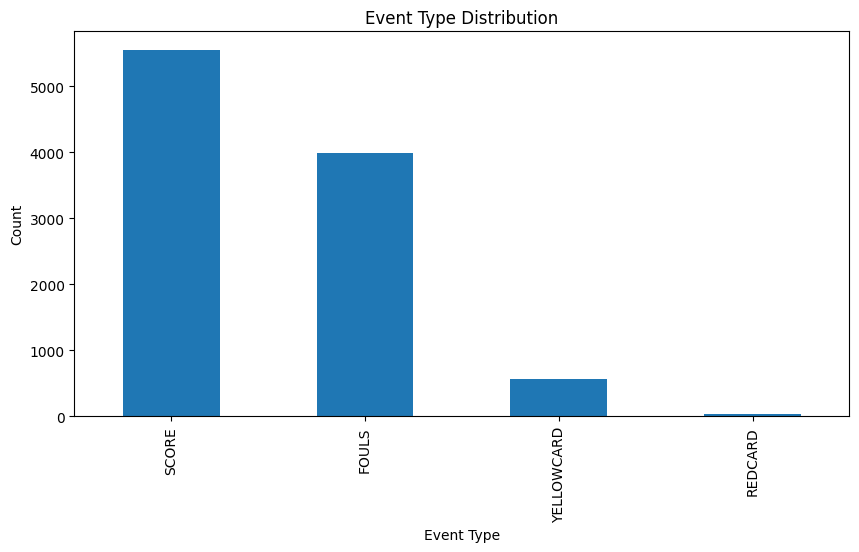

In [216]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# EVENT TYPE DISTRIBUTION
# =============================================================================

print("\nEVENT TYPE COUNTS")

event_counts = (
    players['type']
    .astype(str)
    .str.upper()
    .value_counts()
)

display(event_counts)

# PLOT
plt.figure(figsize=(10,5))

event_counts.plot(kind='bar')

plt.title("Event Type Distribution")

plt.xlabel("Event Type")
plt.ylabel("Count")

plt.show()

In [217]:
# =============================================================================
# UNIQUE PLAYERS
# =============================================================================

unique_players = players['user_id'].nunique()

print("\nUNIQUE PLAYERS:", unique_players)


UNIQUE PLAYERS: 461


In [218]:
# =============================================================================
# UNIQUE MATCHES
# =============================================================================

unique_matches = players['match_id'].nunique()

print("UNIQUE MATCHES:", unique_matches)

UNIQUE MATCHES: 667


In [219]:
# =============================================================================
# EVENTS PER MATCH
# =============================================================================

events_per_match = (

    players.groupby('match_id')
    .size()
)

print("\nEVENTS PER MATCH")

display(events_per_match.describe())


EVENTS PER MATCH


count    667.000000
mean      15.209895
std        5.774623
min        1.000000
25%       11.000000
50%       14.000000
75%       19.000000
max       36.000000
dtype: float64

In [220]:
# =============================================================================
# EVENTS PER PLAYER
# =============================================================================

events_per_player = (

    players.groupby('user_id')
    .size()
)

print("\nEVENTS PER PLAYER")

display(events_per_player.describe())


EVENTS PER PLAYER


count    461.000000
mean      22.006508
std       39.840469
min        1.000000
25%        2.000000
50%        7.000000
75%       22.000000
max      304.000000
dtype: float64

In [221]:
# =============================================================================
# GOAL ANALYSIS
# =============================================================================

players['type'] = (
    players['type']
    .astype(str)
    .str.upper()
)

players['goal'] = np.where(
    players['type'] == 'SCORE',
    1,
    0
)

goal_events = players['goal'].sum()

print("\nTOTAL GOALS:", goal_events)


TOTAL GOALS: 5552


In [222]:
# =============================================================================
# TOP SCORERS
# =============================================================================

top_scorers = (

    players.groupby(
        ['user_id', 'first_name', 'last_name']
    )['goal']

    .sum()

    .sort_values(ascending=False)

    .head(20)
)

print("\nTOP SCORERS")

display(top_scorers)


TOP SCORERS


user_id  first_name  last_name  
737      Claudia     Fruscalzo      217
582      Mary        Hubeek         192
655      Rebecca     Davies         142
517      Laila       Abdullatif     137
670      Jessica     Au             130
8726     Amanda      Eoraha         110
598      Claudia     Dimasi         109
1747     Clarissa    Allerton       109
1768     Deanna      Fruscalzo       88
1780     Camila      Fresneda        84
8508     Daniela     Gudelj          77
11212    Karina      Nautu           73
665      Alycia      Eicke           73
1779     Linda       Sawa            71
506      Taylor      Halabi          69
736      Dharma      Georgi          69
1793     Daniella    Galluccio       68
10092    Lucy        Reimer          68
2427     Bec         Catterwell      63
12220    Annabelle   Mergianos       59
Name: goal, dtype: int64

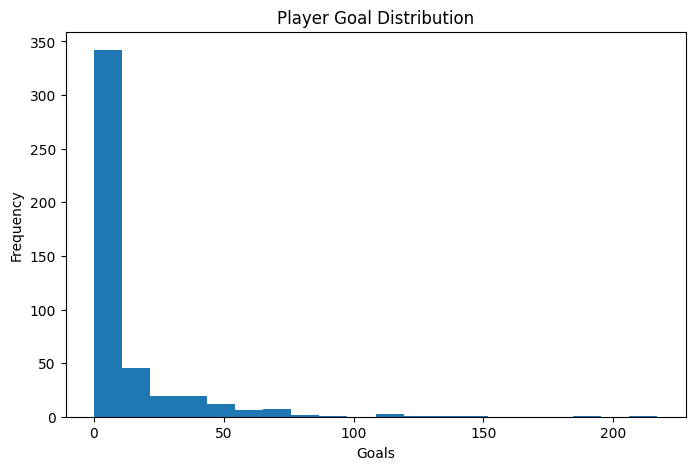

In [223]:
# =============================================================================
# GOALS DISTRIBUTION
# =============================================================================

player_goals = (

    players.groupby('user_id')['goal']
    .sum()
)

plt.figure(figsize=(8,5))

plt.hist(
    player_goals,
    bins=20
)

plt.title("Player Goal Distribution")

plt.xlabel("Goals")
plt.ylabel("Frequency")

plt.show()

In [224]:
# =============================================================================
# ASSIST ANALYSIS
# =============================================================================

players['assist'] = np.where(
    players['assist_player_id'].notnull(),
    1,
    0
)

print("\nTOTAL ASSISTS:")
print(players['assist'].sum())


TOTAL ASSISTS:
1519


In [225]:
# =============================================================================
# FOUL ANALYSIS
# =============================================================================

players['foul'] = np.where(
    players['type'] == 'FOULS',
    1,
    0
)

print("\nTOTAL FOULS:")
print(players['foul'].sum())


TOTAL FOULS:
3994



AGE SUMMARY


count    10087.000000
mean        24.667798
std          5.862209
min          0.000000
25%         21.694730
50%         24.851472
75%         28.372348
max         55.077344
Name: age, dtype: float64

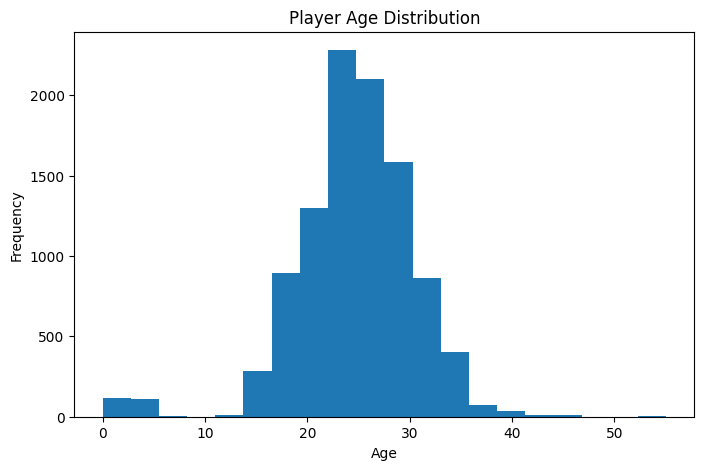

In [226]:
# =============================================================================
# AGE ANALYSIS
# =============================================================================

if 'date_of_birth' in players.columns:

    players['date_of_birth'] = pd.to_datetime(
        players['date_of_birth'],
        errors='coerce'
    )

    players['created_on'] = pd.to_datetime(
        players['created_on'],
        errors='coerce'
    )

    players['age'] = (

        (
            players['created_on']
            -
            players['date_of_birth']
        )

        .dt.days / 365.25
    )

    print("\nAGE SUMMARY")

    display(
        players['age'].describe()
    )

    plt.figure(figsize=(8,5))

    plt.hist(
        players['age'].dropna(),
        bins=20
    )

    plt.title("Player Age Distribution")

    plt.xlabel("Age")

    plt.ylabel("Frequency")

    plt.show()

In [227]:
# =============================================================================
# TEMPORAL COVERAGE
# =============================================================================

players['created_on'] = pd.to_datetime(
    players['created_on'],
    errors='coerce'
)

print("\nDATE RANGE")

print(
    players['created_on'].min(),
    " → ",
    players['created_on'].max()
)


DATE RANGE
2021-05-05 16:44:05  →  2026-06-26 18:16:42


In [228]:
# =============================================================================
# PLAYER ACTIVITY DISTRIBUTION
# =============================================================================

matches_per_player = (

    players.groupby('user_id')['match_id']
    .nunique()
)

print("\nMATCHES PER PLAYER")

display(
    matches_per_player.describe()
)


MATCHES PER PLAYER


count    461.000000
mean      11.370933
std       18.151031
min        1.000000
25%        1.000000
50%        4.000000
75%       12.000000
max      120.000000
Name: match_id, dtype: float64

In [229]:
# =============================================================================
# LOW DATA PLAYERS
# =============================================================================

low_data_players = (
    matches_per_player < 3
).sum()

print("\nPLAYERS WITH <3 MATCHES:")
print(low_data_players)



PLAYERS WITH <3 MATCHES:
182


### Feature Engineering

In [230]:
import pandas as pd
import numpy as np

players['created_on'] = pd.to_datetime(
    players['created_on'],
    errors='coerce'
)

matches['startDate'] = pd.to_datetime(
    matches['startDate'],
    errors='coerce'
)

# =====================================================
# GOALS
# =====================================================

goals_df = (
    players[players['type'] == 'SCORE']
    .groupby(['match_id','user_id'])
    .size()
    .reset_index(name='goals')
)

# =====================================================
# FOULS
# =====================================================

fouls_df = (
    players[players['type'] == 'FOULS']
    .groupby(['match_id','user_id'])
    .size()
    .reset_index(name='fouls')
)

# =====================================================
# YELLOW CARDS
# =====================================================

yellow_df = (
    players[players['type'] == 'YELLOWCARD']
    .groupby(['match_id','user_id'])
    .size()
    .reset_index(name='yellow_cards')
)

# =====================================================
# RED CARDS
# =====================================================

red_df = (
    players[players['type'] == 'REDCARD']
    .groupby(['match_id','user_id'])
    .size()
    .reset_index(name='red_cards')
)

In [231]:
assist_df = (
    players[
        players['assist_player_id'].notna()
    ]
    .groupby(
        ['match_id','assist_player_id']
    )
    .size()
    .reset_index(name='assists')
)

assist_df.rename(
    columns={
        'assist_player_id':'user_id'
    },
    inplace=True
)

In [232]:
player_match = pd.concat([

    goals_df[['match_id','user_id']],
    fouls_df[['match_id','user_id']],
    yellow_df[['match_id','user_id']],
    red_df[['match_id','user_id']],
    assist_df[['match_id','user_id']]

]).drop_duplicates()

In [233]:
dfs = [
    goals_df,
    fouls_df,
    yellow_df,
    red_df,
    assist_df
]

for df in dfs:

    player_match = player_match.merge(
        df,
        on=['match_id','user_id'],
        how='left'
    )

player_match.fillna(0, inplace=True)

In [234]:
player_info = (
    players[
        [
            'match_id',
            'user_id',
            'team_id',
            'first_name',
            'last_name',
            'date_of_birth'
        ]
    ]

    .drop_duplicates(
        ['match_id','user_id']
    )
)

player_match = player_match.merge(
    player_info,
    on=['match_id','user_id'],
    how='left'
)

In [235]:
match_cols = [

    'id',

    'startDate',

    'homeTeamId',
    'awayTeamId',

    'homeTeamName',
    'awayTeamName',

    'competitionName',
    'seasonName'
]

player_match = player_match.merge(

    matches[match_cols],

    left_on='match_id',
    right_on='id',

    how='left'
)

player_match.drop(
    columns=['id'],
    inplace=True
)

player_match.rename(
    columns={'startDate':'match_date'},
    inplace=True
)

In [236]:
player_match['player_name'] = (

    player_match['first_name'].fillna('')

    + ' '

    +

    player_match['last_name'].fillna('')
)

player_match['match_date'] = pd.to_datetime(
    player_match['match_date']
)

player_match['date_of_birth'] = pd.to_datetime(
    player_match['date_of_birth'],
    errors='coerce'
)

player_match['age'] = (

    (
        player_match['match_date']
        -
        player_match['date_of_birth']
    ).dt.days

) / 365.25

In [237]:
player_match = player_match.sort_values(
    ['user_id','match_date']
)

In [238]:
player_match['goal_contribution'] = (

    player_match['goals']
    +
    player_match['assists']
)

player_match['clutch_goals'] = (
    player_match['goals'] >= 2
).astype(int)

player_match['perf_score'] = (

    player_match['goals'] * 3

    + player_match['assists'] * 2

    + player_match['clutch_goals'] * 1.5

    - player_match['fouls'] * 0.5

    - player_match['yellow_cards']

    - player_match['red_cards'] * 3
)

In [239]:
player_match['career_matches'] = (
    player_match.groupby('user_id')
    .cumcount()
)

player_match['career_goals'] = (
    player_match.groupby('user_id')['goals']
    .cumsum()
    -
    player_match['goals']
)

player_match['career_assists'] = (
    player_match.groupby('user_id')['assists']
    .cumsum()
    -
    player_match['assists']
)

player_match['career_perf_score'] = (
    player_match.groupby('user_id')['perf_score']
    .cumsum()
    -
    player_match['perf_score']
)

In [240]:
player_match['career_gpg'] = (

    player_match['career_goals']

    /

    player_match['career_matches']
    .replace(0,np.nan)
)

player_match['career_apg'] = (

    player_match['career_assists']

    /

    player_match['career_matches']
    .replace(0,np.nan)
)

player_match['career_avg_perf'] = (

    player_match['career_perf_score']

    /

    player_match['career_matches']
    .replace(0,np.nan)
)

In [241]:
for w in [3,5,10]:

    player_match[f'roll{w}_goals'] = (
        player_match.groupby('user_id')['goals']
        .transform(
            lambda x:
            x.shift(1)
            .rolling(w,min_periods=1)
            .mean()
        )
    )

    player_match[f'roll{w}_assists'] = (
        player_match.groupby('user_id')['assists']
        .transform(
            lambda x:
            x.shift(1)
            .rolling(w,min_periods=1)
            .mean()
        )
    )

    player_match[f'roll{w}_perf_score'] = (
        player_match.groupby('user_id')['perf_score']
        .transform(
            lambda x:
            x.shift(1)
            .rolling(w,min_periods=1)
            .mean()
        )
    )

In [242]:
player_match['ewm_goals'] = (
    player_match.groupby('user_id')['goals']
    .transform(
        lambda x:
        x.shift(1)
        .ewm(span=5)
        .mean()
    )
)

player_match['ewm_assists'] = (
    player_match.groupby('user_id')['assists']
    .transform(
        lambda x:
        x.shift(1)
        .ewm(span=5)
        .mean()
    )
)

player_match['ewm_perf_score'] = (
    player_match.groupby('user_id')['perf_score']
    .transform(
        lambda x:
        x.shift(1)
        .ewm(span=5)
        .mean()
    )
)

In [243]:
player_match['goal_trend'] = (
    player_match['roll5_goals']
    -
    player_match['career_gpg']
)

player_match['assist_trend'] = (
    player_match['roll5_assists']
    -
    player_match['career_apg']
)

player_match['perf_trend'] = (
    player_match['roll5_perf_score']
    -
    player_match['career_avg_perf']
)

player_match['prev_match_date'] = (
    player_match.groupby('user_id')
    ['match_date']
    .shift(1)
)

player_match['days_since_last_match'] = (
    player_match['match_date']
    -
    player_match['prev_match_date']
).dt.days

player_match['days_since_last_match'] = (
    player_match['days_since_last_match']
    .fillna(-1)
)

player_match['experience_score'] = (

    np.log1p(
        player_match['career_matches']
    )

    *

    np.log1p(
        player_match['career_goals'] + 1
    )
)

In [244]:
player_match['age'] = player_match['age'].fillna(
    player_match['age'].median()
)

In [245]:
player_match['log_career_goals'] = np.log1p(
    player_match['career_goals']
)

player_match['log_career_assists'] = np.log1p(
    player_match['career_assists']
)

player_match['log_career_matches'] = np.log1p(
    player_match['career_matches']
)

# Numeric columns
num_cols = player_match.select_dtypes(
    include=np.number
).columns

player_match[num_cols] = (
    player_match[num_cols]
    .fillna(0)
)

player_match['best_match_score'] = (
    player_match.groupby('match_id')['perf_score']
    .transform('max')
)

player_match['is_best_player'] = (
    player_match['perf_score']
    ==
    player_match['best_match_score']
).astype(int)



In [246]:
# save filtered data in temp variable
temp = player_match[player_match['team_id'] != 0].copy()

# now remove those rows from original dataframe
player_match = player_match.drop(player_match[player_match['team_id'] == 0].index)

In [247]:
player_match.to_csv(
    "Futsal_match_ml.csv",
    index=False
)

print(player_match.shape)
player_match.head()

(5242, 53)


,match_id,user_id,goals,fouls,yellow_cards,red_cards,assists,team_id,first_name,last_name,...,assist_trend,perf_trend,prev_match_date,days_since_last_match,experience_score,log_career_goals,log_career_assists,log_career_matches,best_match_score,is_best_player
304,56170,446.0,2.0,1.0,0.0,0.0,0.0,927.0,Finley,Nobbs,...,0.0,0.0,NaT,-1.0,0.000000,0.000000,0.0,0.000000,10.5,0
3684,75809,446.0,0.0,2.0,0.0,0.0,0.0,927.0,Finley,Nobbs,...,0.0,0.0,2022-04-06,175.0,0.960906,1.098612,0.0,0.693147,3.0,0
5170,75831,446.0,0.0,0.0,1.0,0.0,0.0,927.0,Finley,Nobbs,...,0.0,0.0,2022-09-28,35.0,1.523000,1.098612,0.0,1.098612,7.5,0
760,75833,446.0,2.0,1.0,0.0,0.0,0.0,927.0,Finley,Nobbs,...,0.0,0.0,2022-11-02,7.0,1.921812,1.098612,0.0,1.386294,13.0,0
3790,75846,446.0,0.0,1.0,0.0,0.0,0.0,927.0,Finley,Nobbs,...,0.0,0.0,2022-11-09,21.0,2.883726,1.609438,0.0,1.609438,10.5,0


In [248]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [249]:
df = pd.read_csv(
    "Futsal_match_ml.csv"
)

print(df.shape)
df.head()

(5242, 53)


,match_id,user_id,goals,fouls,yellow_cards,red_cards,assists,team_id,first_name,last_name,...,assist_trend,perf_trend,prev_match_date,days_since_last_match,experience_score,log_career_goals,log_career_assists,log_career_matches,best_match_score,is_best_player
0,56170,446.0,2.0,1.0,0.0,0.0,0.0,927.0,Finley,Nobbs,...,0.0,0.0,NaN,-1.0,0.000000,0.000000,0.0,0.000000,10.5,0
1,75809,446.0,0.0,2.0,0.0,0.0,0.0,927.0,Finley,Nobbs,...,0.0,0.0,2022-04-06,175.0,0.960906,1.098612,0.0,0.693147,3.0,0
2,75831,446.0,0.0,0.0,1.0,0.0,0.0,927.0,Finley,Nobbs,...,0.0,0.0,2022-09-28,35.0,1.523000,1.098612,0.0,1.098612,7.5,0
3,75833,446.0,2.0,1.0,0.0,0.0,0.0,927.0,Finley,Nobbs,...,0.0,0.0,2022-11-02,7.0,1.921812,1.098612,0.0,1.386294,13.0,0
4,75846,446.0,0.0,1.0,0.0,0.0,0.0,927.0,Finley,Nobbs,...,0.0,0.0,2022-11-09,21.0,2.883726,1.609438,0.0,1.609438,10.5,0


In [250]:
DROP_COLS = [

    'match_id',
    'user_id',

    'player_name',
    'first_name',
    'last_name',

    'date_of_birth',
    'match_date',
    'prev_match_date',

    'goals',
    'assists',
    'fouls',
    'yellow_cards',
    'red_cards',

    'goal_contribution',
    'clutch_goals',
    'perf_score',
    'homeTeamName',
    'awayTeamName',
    'competitionName',
    'seasonName',

    'best_match_score',

    'is_best_player'
]

X = df.drop(
    columns=DROP_COLS,
    errors='ignore'
)

y = df['is_best_player']

print(X)

      team_id  homeTeamId  awayTeamId        age  career_matches  \
0       927.0       927.0        29.0  24.594114               0   
1       927.0       927.0       936.0  25.073238               1   
2       927.0       927.0        31.0  25.169062               2   
3       927.0       927.0       406.0  25.188227               3   
4       927.0        28.0       927.0  25.245722               4   
...       ...         ...         ...        ...             ...   
5237   1845.0      3485.0      1845.0  23.104723               1   
5238   3487.0        26.0      3487.0  23.953457               0   
5239   3487.0      1845.0      3487.0  23.991786               1   
5240   3487.0        26.0      3487.0  24.049281               2   
5241     29.0      1845.0        29.0  15.036277               0   

      career_goals  career_assists  career_perf_score  career_gpg  career_apg  \
0              0.0             0.0                0.0    0.000000         0.0   
1              2.0   

In [251]:
feature_names = X.columns.tolist()

joblib.dump(
    feature_names,
    "feature_names.pkl"
)

print(
    f"Saved {len(feature_names)} features"
)

Saved 31 features


In [252]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    stratify=y,

    random_state=42
)

In [253]:
MODELS = {

    "XGBoost": XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=7.5,
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        class_weight='balanced',
        random_state=42
    ),

    "CatBoost": CatBoostClassifier(
        auto_class_weights='Balanced',
        verbose=0,
        random_state=42
    )
}

In [254]:
PARAMS = {

    "XGBoost": {

        'n_estimators':[100,200],

        'max_depth':[3,5,7],

        'learning_rate':[0.01,0.05,0.1]
    },

    "LightGBM": {

        'n_estimators':[100,200],

        'max_depth':[3,5,7],

        'learning_rate':[0.01,0.05,0.1]
    },

    "CatBoost": {

        'depth':[4,6,8],

        'learning_rate':[0.01,0.05,0.1],

        'iterations':[200,500]
    }
}

In [255]:
def evaluate_model(
    model,
    X_test,
    y_test
):

    preds = model.predict(
        X_test
    )

    probs = model.predict_proba(
        X_test
    )[:,1]

    results = {

        "Accuracy":
        accuracy_score(
            y_test,
            preds
        ),

        "Precision":
        precision_score(
            y_test,
            preds
        ),

        "Recall":
        recall_score(
            y_test,
            preds
        ),

        "F1":
        f1_score(
            y_test,
            preds
        ),

        "ROC_AUC":
        roc_auc_score(
            y_test,
            probs
        )
    }

    return results

In [256]:
def train_model(

    model_name,
    model,

    param_grid,

    X_train,
    y_train
):

    print(
        f"\nTraining {model_name}"
    )

    grid = GridSearchCV(

        estimator=model,

        param_grid=param_grid,

        scoring='f1',

        cv=5,

        n_jobs=-1,

        verbose=2
    )

    grid.fit(
        X_train,
        y_train
    )

    print(
        f"Best Score: {grid.best_score_}"
    )

    print(
        f"Best Params: {grid.best_params_}"
    )

    return grid

In [257]:
all_results = []

trained_models = {}

for model_name in MODELS:

    grid = train_model(

        model_name,

        MODELS[model_name],

        PARAMS[model_name],

        X_train,
        y_train
    )

    trained_models[model_name] = grid

    metrics = evaluate_model(

        grid.best_estimator_,

        X_test,
        y_test
    )

    metrics['Model'] = model_name

    metrics['CV_F1'] = (
        grid.best_score_
    )

    all_results.append(
        metrics
    )


Training XGBoost
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Score: 0.3408431590972757
Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

Training LightGBM
Fitting 5 folds for each of 18 candidates, totalling 90 fits
[LightGBM] [Info] Number of positive: 650, number of negative: 3543
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001160 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3868
[LightGBM] [Info] Number of data points in the train set: 4193, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No

In [258]:
results_df = pd.DataFrame(
    all_results
)

results_df = results_df.sort_values(
    'CV_F1',
    ascending=False
)

display(results_df)

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,CV_F1
2,0.548141,0.208255,0.680982,0.318966,0.658477,CatBoost,0.348618
1,0.551001,0.217949,0.730061,0.335684,0.649677,LightGBM,0.344055
0,0.461392,0.199102,0.815951,0.320096,0.659793,XGBoost,0.340843


In [259]:
# for model_name, grid in trained_models.items():

#     filename = (
#         model_name
#         .lower()
#         .replace(" ","_")
#         + ".pkl"
#     )

#     joblib.dump(
#         grid.best_estimator_,
#         filename
#     )

#     print(
#         f"Saved {filename}"
#     )

In [260]:
best_model_name = (
    results_df.iloc[0]['Model']
)

best_model = (

    trained_models[
        best_model_name
    ]

    .best_estimator_
)

joblib.dump(

    best_model,

    f"{best_model_name}_players_model.pkl"
)

print(
    f"Best Model: {best_model_name}"
)

print(
    "Saved as best_player_model.pkl"
)

Best Model: CatBoost
Saved as best_player_model.pkl


In [264]:
pred_best = test_df.copy()

pred_best["pred_prob"] = best_model.predict_proba(X_test)[:,1]

pred_best_player = (
    pred_best
    .sort_values(
        ["match_id","pred_prob"],
        ascending=[True,False]
    )
    .groupby("match_id")
    .head(1)
)

ValueError: Length of values (1049) does not match length of index (1001)

In [265]:
print("test_df:", len(test_df))
print("X_test:", len(X_test))
print("y_test:", len(y_test))

test_df: 1001
X_test: 1049
y_test: 1049


In [268]:
!uv add imbalanced-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ------------ --------------------------- 2.6/8.3 MB 12.1 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.3 MB 12.0 MB/s eta 0:00:01
   ------------------------------------ --- 7.6/8.3 MB 11.9 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 11.5 MB/s  0:00:00
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   - -------------------------------------- 1.8/37.3 MB 8.9 MB/s eta 0:00:04
   ----- ---------------------------------- 4.7/37.3 MB 10.9 MB/s eta 0:00:03
   ------ --------------------------------- 6.0/37.3 MB 9.6 MB/s eta 0:00:04
   ------- -------------------------------- 7.1/37.3 MB 8.2 MB/s eta 0:00:04
   -------- ------------------------------- 8.4/37.3 MB 7.9 MB/s eta 0:00:04
   --------- ------------------------------ 9.2/37.3 MB 7.2 MB/s eta 0:00:04
   --------- ------------------------------ 9.2/37.3 MB 7.2 MB/s eta 0:00:04
   ---------- --


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\ADMIN\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip
Resolved 229 packages in 6.00s
Prepared 2 packages in 590ms
Installed 2 packages in 94ms
 + imbalanced-learn==0.14.2
 + sklearn-compat==0.1.6


In [270]:
from imblearn.over_sampling import SMOTE

# Original split
X_train = train_df[FEATURES]
y_train = train_df["is_best_player"]

X_test = test_df[FEATURES]
y_test = test_df["is_best_player"]

# Apply SMOTE ONLY on training data
smote = SMOTE(
    sampling_strategy=0.5,
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(X_train_smote.shape)
print(y_train_smote.shape)

print(X_test.shape)
print(y_test.shape)

(5218, 50)
(5218,)
(1001, 50)
(1001,)


In [271]:
best_model.fit(
    X_train_smote,
    y_train_smote
)

CatBoostClassifier(auto_class_weights='Balanced', depth=4, iterations=500, learning_rate=0.01, random_state=42, verbose=0)

In [272]:
preds = best_model.predict(X_test)
probs = best_model.predict_proba(X_test)[:,1]

In [273]:
pred_best = test_df.copy()

pred_best["pred_prob"] = best_model.predict_proba(X_test)[:,1]

In [274]:
print(len(pred_best))
print(len(X_test))

1001
1001


In [275]:
pred_best_player = (
    pred_best
    .sort_values(
        ["match_id", "pred_prob"],
        ascending=[True, False]
    )
    .groupby("match_id")
    .head(1)
)

In [276]:
top1_accuracy = pred_best_player["is_best_player"].mean()

print("Top-1 MVP Accuracy:", top1_accuracy)

Top-1 MVP Accuracy: 0.26618705035971224


In [277]:
print("Matches:", pred_best_player["match_id"].nunique())

Matches: 139


In [261]:
# results_df.to_csv(
#     "model_comparison.csv",
#     index=False
# )

# results_df

In [262]:
import pandas as pd
import numpy as np
import joblib

# ============================================================
# LOAD FILES
# ============================================================

BEST_PLAYER_MODEL = joblib.load("best_player_model.pkl")
FEATURE_COLUMNS = joblib.load("feature_names.pkl")

player_df = pd.read_csv("Futsal_match_ml.csv")

# ============================================================
# INFERENCE FUNCTION
# ============================================================

def predict_best_player(match_prediction_json):

    home_id = match_prediction_json["homeID"]
    away_id = match_prediction_json["awayID"]

    predicted_winner_name = match_prediction_json["prediction"]

    # --------------------------------------------------------
    # GET TEAM NAME MAPPING
    # --------------------------------------------------------

    team_mapping = (
        player_df[
            ["team_id"]
        ]
        .drop_duplicates()
    )

    # --------------------------------------------------------
    # FIND WINNING TEAM ID
    # --------------------------------------------------------

    latest_rows = player_df.sort_values(
        "match_date"
    )

    home_team_name = (
        latest_rows[
            latest_rows["homeTeamId"] == home_id
        ]["homeTeamName"]
        .dropna()
        .iloc[-1]
    )

    away_team_name = (
        latest_rows[
            latest_rows["awayTeamId"] == away_id
        ]["awayTeamName"]
        .dropna()
        .iloc[-1]
    )

    if predicted_winner_name == home_team_name:
        winning_team_id = home_id
    else:
        winning_team_id = away_id

    # --------------------------------------------------------
    # LATEST PLAYER FEATURES
    # --------------------------------------------------------

    latest_player_features = (
        player_df
        .sort_values("match_date")
        .groupby("user_id")
        .tail(1)
    )

    winning_players = latest_player_features[
        latest_player_features["team_id"] == winning_team_id
    ].copy()

    if len(winning_players) == 0:
        return {
            "error": "No player data found"
        }

    # --------------------------------------------------------
    # MODEL PREDICTION
    # --------------------------------------------------------

    X_players = winning_players[
        FEATURE_COLUMNS
    ]

    winning_players["best_player_probability"] = (
        BEST_PLAYER_MODEL.predict_proba(X_players)[:,1]
    )

    winning_players = winning_players.sort_values(
        "best_player_probability",
        ascending=False
    )

    # --------------------------------------------------------
    # BEST PLAYER
    # --------------------------------------------------------

    best_player_name = (
        winning_players.iloc[0]["player_name"]
    )

    # --------------------------------------------------------
    # PLAYER LIST
    # --------------------------------------------------------

    player_predictions = []

    for _, row in winning_players.iterrows():

        player_predictions.append({
            "playerName": row["player_name"],
            "playerID": int(row["user_id"]),
            "probability": round(
                float(
                    row["best_player_probability"]
                ) * 100,
                2
            )
        })

    # --------------------------------------------------------
    # FINAL OUTPUT
    # --------------------------------------------------------

    result = {
        "homeTeam": home_team_name,
        "awayTeam": away_team_name,
        "homeWinProbability": round(
            match_prediction_json["confidence"],
            2
        ),
        "awayWinProbability": round(
            100 - match_prediction_json["confidence"],
            2
        ),
        "predictedWinner": predicted_winner_name,
        "predictedBestPlayer": best_player_name,
        "winningTeamPlayers": player_predictions[:5]
    }

    return result


# ============================================================
# SAMPLE INPUT
# ============================================================

match_input = {
    "homeID": 331,
    "awayID": 344,
    "prediction": "Hume FC",
    "confidence": 89.49
}

result = predict_best_player(match_input)

print(result)

IndexError: single positional indexer is out-of-bounds

In [ ]:
import pandas as pd

importance = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "importance": best_model.feature_importances_
})

importance.sort_values(
    "importance",
    ascending=False
).head(20)

,feature,importance
10,career_avg_perf,0.274541
17,roll10_goals,0.088871
8,career_gpg,0.071568
6,career_assists,0.062294
19,roll10_perf_score,0.041824
1,homeTeamId,0.038008
11,roll3_goals,0.036881
0,team_id,0.033864
5,career_goals,0.032824
22,ewm_perf_score,0.032801


# Trial and Checking

In [ ]:
# ==========================================
# PHASE 1 : DATASET AUDIT
# ==========================================

print("Rows:", player_match.shape[0])
print("Columns:", player_match.shape[1])

print("\nUnique Matches:")
print(player_match['match_id'].nunique())

print("\nUnique Players:")
print(player_match['user_id'].nunique())

Rows: 5242
Columns: 53

Unique Matches:
667

Unique Players:
461


In [ ]:
print(player_match['is_best_player'].value_counts())

print("\nPercentage")
print(
    player_match['is_best_player']
    .value_counts(normalize=True)
    * 100
)

is_best_player
0    4429
1     813
Name: count, dtype: int64

Percentage
is_best_player
0    84.490652
1    15.509348
Name: proportion, dtype: float64


In [ ]:
best_per_match = (
    player_match
    .groupby('match_id')['is_best_player']
    .sum()
)

print(best_per_match.describe())

print("\nMatches with >1 winner")
print((best_per_match > 1).sum())

print("\nMatches with 0 winner")
print((best_per_match == 0).sum())

count    667.000000
mean       1.218891
std        0.868226
min        0.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        6.000000
Name: is_best_player, dtype: float64

Matches with >1 winner
147

Matches with 0 winner
80


In [ ]:
player_history = (
    player_match
    .groupby('user_id')['match_id']
    .nunique()
)

print(player_history.describe())

count    461.000000
mean      11.370933
std       18.151031
min        1.000000
25%        1.000000
50%        4.000000
75%       12.000000
max      120.000000
Name: match_id, dtype: float64


In [ ]:
print("Players with <3 matches")

print(
    (player_history < 3).sum()
)

Players with <3 matches
182


In [ ]:
target = "is_best_player"

numeric_cols = player_match.select_dtypes(
    include='number'
)

corr = (
    numeric_cols
    .corr()[target]
    .sort_values(ascending=False)
)

print(corr.head(25))

is_best_player        1.000000
perf_score            0.487642
goals                 0.476758
clutch_goals          0.468936
goal_contribution     0.453483
roll10_goals          0.139354
career_gpg            0.134760
roll5_goals           0.134460
ewm_goals             0.133980
career_avg_perf       0.132348
roll10_perf_score     0.132157
roll5_perf_score      0.125999
ewm_perf_score        0.124757
roll3_goals           0.122778
roll3_perf_score      0.113739
log_career_goals      0.085841
career_perf_score     0.075781
career_goals          0.069133
experience_score      0.063575
age                   0.052938
log_career_matches    0.040265
goal_trend            0.037703
career_matches        0.030922
perf_trend            0.028123
assists              -0.017215
Name: is_best_player, dtype: float64


## Correction

In [ ]:
player_match.drop(
    columns=[
        'best_match_score',
        'is_best_player'
    ],
    errors='ignore',
    inplace=True
)

In [ ]:
player_match['rank_in_match'] = (

    player_match
    .groupby('match_id')['perf_score']
    .rank(
        method='first',
        ascending=False
    )
)

In [ ]:
player_match['is_best_player'] = (
    player_match['rank_in_match'] == 1
).astype(int)

In [ ]:
best_per_match = (
    player_match
    .groupby('match_id')['is_best_player']
    .sum()
)

print(best_per_match.describe())

print("Multiple winners:",
      (best_per_match > 1).sum())

print("Zero winners:",
      (best_per_match == 0).sum())

count    667.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: is_best_player, dtype: float64
Multiple winners: 0
Zero winners: 0


### Phase-3

In [ ]:
player_history = (
    player_match
    .groupby('user_id')['match_id']
    .nunique()
)

valid_players = player_history[
    player_history >= 3
].index

player_match = player_match[
    player_match['user_id']
    .isin(valid_players)
].copy()

In [ ]:
print(player_match.shape)

print(
    player_match['user_id']
    .nunique()
)

(5002, 53)
279


In [ ]:
print(
    player_match['is_best_player']
    .value_counts()
)

is_best_player
0    4350
1     652
Name: count, dtype: int64


In [ ]:
print(player_match.columns.tolist())

['match_id', 'user_id', 'goals', 'fouls', 'yellow_cards', 'red_cards', 'assists', 'team_id', 'first_name', 'last_name', 'date_of_birth', 'match_date', 'homeTeamId', 'awayTeamId', 'homeTeamName', 'awayTeamName', 'competitionName', 'seasonName', 'player_name', 'age', 'goal_contribution', 'clutch_goals', 'perf_score', 'career_matches', 'career_goals', 'career_assists', 'career_perf_score', 'career_gpg', 'career_apg', 'career_avg_perf', 'roll3_goals', 'roll3_assists', 'roll3_perf_score', 'roll5_goals', 'roll5_assists', 'roll5_perf_score', 'roll10_goals', 'roll10_assists', 'roll10_perf_score', 'ewm_goals', 'ewm_assists', 'ewm_perf_score', 'goal_trend', 'assist_trend', 'perf_trend', 'prev_match_date', 'days_since_last_match', 'experience_score', 'log_career_goals', 'log_career_assists', 'log_career_matches', 'rank_in_match', 'is_best_player']


In [ ]:
# ==================================
# TEAM GOALS PER MATCH
# ==================================

team_match_stats = (

    player_match

    .groupby(
        ['match_id', 'team_id', 'match_date']
    )

    .agg({

        'goals':'sum',
        'assists':'sum',
        'perf_score':'sum'

    })

    .reset_index()

)

team_match_stats.head()

,match_id,team_id,match_date,goals,assists,perf_score
0,42222,25.0,2021-05-05,0.0,0.0,-4.0
1,42222,29.0,2021-05-05,6.0,0.0,21.0
2,42223,26.0,2021-05-05,0.0,0.0,-5.5
3,42223,30.0,2021-05-05,5.0,0.0,15.0
4,42224,28.0,2021-05-05,1.0,0.0,3.0


In [ ]:
team_match_stats = team_match_stats.sort_values(
    ['team_id','match_date']
)

In [ ]:
team_match_stats['team_avg_goals'] = (

    team_match_stats

    .groupby('team_id')['goals']

    .transform(

        lambda x:

        x.shift(1)

        .expanding()

        .mean()

    )
)

In [ ]:
team_match_stats['team_avg_assists'] = (

    team_match_stats

    .groupby('team_id')['assists']

    .transform(

        lambda x:

        x.shift(1)

        .expanding()

        .mean()

    )
)

In [ ]:
team_match_stats['team_avg_perf'] = (

    team_match_stats

    .groupby('team_id')['perf_score']

    .transform(

        lambda x:

        x.shift(1)

        .expanding()

        .mean()

    )
)

In [ ]:
team_match_stats['team_form_3'] = (

    team_match_stats

    .groupby('team_id')['goals']

    .transform(

        lambda x:

        x.shift(1)

        .rolling(
            3,
            min_periods=1
        )

        .mean()

    )
)

In [ ]:
team_match_stats['team_form_5'] = (

    team_match_stats

    .groupby('team_id')['goals']

    .transform(

        lambda x:

        x.shift(1)

        .rolling(
            5,
            min_periods=1
        )

        .mean()

    )
)

In [ ]:
team_features = [

    'match_id',
    'team_id',

    'team_avg_goals',
    'team_avg_assists',
    'team_avg_perf',

    'team_form_3',
    'team_form_5'

]

player_match = player_match.merge(

    team_match_stats[
        team_features
    ],

    on=[
        'match_id',
        'team_id'
    ],

    how='left'

)

In [ ]:
team_cols = [

    'team_avg_goals',
    'team_avg_assists',
    'team_avg_perf',

    'team_form_3',
    'team_form_5'

]

player_match[team_cols] = (
    player_match[team_cols]
    .fillna(0)
)

In [ ]:
player_match[[
    'team_avg_goals',
    'team_avg_assists',
    'team_avg_perf',
    'team_form_3',
    'team_form_5'
]].describe()

,team_avg_goals,team_avg_assists,team_avg_perf,team_form_3,team_form_5
count,5002.000000,5002.000000,5002.000000,5002.000000,5002.000000
mean,3.693940,0.016896,10.481812,4.263495,4.228619
std,1.298136,0.071091,4.417201,2.655478,2.245092
min,0.000000,0.000000,-5.500000,0.000000,0.000000
25%,2.778947,0.000000,7.400000,2.333333,2.600000
50%,3.629630,0.000000,10.148936,3.666667,3.800000
75%,4.596154,0.000000,13.588496,5.666667,5.600000
max,8.000000,0.769231,25.750000,18.333333,14.400000


In [ ]:
player_match['is_home'] = (
    player_match['team_id']
    ==
    player_match['homeTeamId']
).astype(int)

In [ ]:
player_match['is_home'].value_counts()

is_home
1    2596
0    2406
Name: count, dtype: int64

In [ ]:
player_match['opponent_team_id'] = np.where(

    player_match['team_id']
    ==
    player_match['homeTeamId'],

    player_match['awayTeamId'],

    player_match['homeTeamId']
)

In [ ]:
team_strength = team_match_stats[[
    'match_id',
    'team_id',
    'team_avg_goals',
    'team_avg_perf',
    'team_form_3',
    'team_form_5'
]].copy()

In [ ]:
team_strength.columns = [

    'match_id',

    'opponent_team_id',

    'opp_avg_goals',

    'opp_avg_perf',

    'opp_form_3',

    'opp_form_5'
]

In [ ]:
player_match = player_match.merge(

    team_strength,

    on=[
        'match_id',
        'opponent_team_id'
    ],

    how='left'
)

In [ ]:
opp_cols = [

    'opp_avg_goals',
    'opp_avg_perf',

    'opp_form_3',
    'opp_form_5'
]

player_match[opp_cols] = (
    player_match[opp_cols]
    .fillna(0)
)

In [ ]:
player_match['goal_strength_diff'] = (

    player_match['team_avg_goals']

    -

    player_match['opp_avg_goals']
)

In [ ]:
player_match['perf_strength_diff'] = (

    player_match['team_avg_perf']

    -

    player_match['opp_avg_perf']
)

In [ ]:
player_match['form3_diff'] = (

    player_match['team_form_3']

    -

    player_match['opp_form_3']
)

In [ ]:
player_match['form5_diff'] = (

    player_match['team_form_5']

    -

    player_match['opp_form_5']
)

In [ ]:
player_match[[
    'is_home',

    'goal_strength_diff',
    'perf_strength_diff',

    'form3_diff',
    'form5_diff'
]].describe()

,is_home,goal_strength_diff,perf_strength_diff,form3_diff,form5_diff
count,5002.000000,5002.000000,5002.000000,5002.000000,5002.000000
mean,0.518992,0.308562,0.986965,0.379681,0.381504
std,0.499689,1.962881,6.598473,3.445760,2.937150
min,0.000000,-6.000000,-21.000000,-13.666667,-10.600000
25%,0.000000,-1.093555,-3.623841,-1.666667,-1.587500
50%,1.000000,0.307692,1.144231,0.333333,0.400000
75%,1.000000,1.777778,5.944862,2.333333,2.400000
max,1.000000,7.307692,24.500000,14.333333,10.600000


In [ ]:
player_match['is_home'].value_counts()

is_home
1    2596
0    2406
Name: count, dtype: int64

In [ ]:
team_career_goals = (

    player_match

    .groupby(['team_id'])

    ['career_goals']

    .transform('max')
)

In [ ]:
player_match['goal_share'] = (

    player_match['career_goals']

    /

    (
        team_career_goals + 1
    )
)

In [ ]:
team_career_assists = (

    player_match

    .groupby(['team_id'])

    ['career_assists']

    .transform('max')
)

In [ ]:
player_match['assist_share'] = (

    player_match['career_assists']

    /

    (
        team_career_assists + 1
    )
)

In [ ]:
player_match['recent_goal_boost'] = (

    player_match['roll5_goals']

    /

    (
        player_match['career_gpg']
        + 0.01
    )
)

In [ ]:
player_match['recent_perf_boost'] = (

    player_match['roll5_perf_score']

    /

    (
        player_match['career_avg_perf']
        + 0.01
    )
)

In [ ]:
player_match['experience_bucket'] = pd.cut(
    player_match['career_matches'],
    bins=[-1, 5, 15, 30, np.inf],
    labels=[0, 1, 2, 3]
).astype(int)

In [ ]:
# ==========================================
# MATCH RANK FEATURES
# ==========================================

rank_features = [
    "career_gpg",
    "career_avg_perf",
    "roll10_goals",
    "roll10_perf_score",
    "goal_share"
]

for col in rank_features:

    player_match[f"{col}_rank"] = (
        player_match
        .groupby("match_id")[col]
        .rank(
            method="dense",
            ascending=False
        )
    )

# ==========================================
# HISTORICAL MVP FEATURES
# ==========================================

player_match = player_match.sort_values(
    ["user_id", "match_date"]
)

player_match["prev_best_player_count"] = (
    player_match
    .groupby("user_id")["is_best_player"]
    .transform(
        lambda x:
        x.shift(1)
         .fillna(0)
         .cumsum()
    )
)

player_match["best_player_rate"] = (
    player_match["prev_best_player_count"]
    /
    (player_match["career_matches"] + 1)
)

# ==========================================
# TEAM RELATIVE STRENGTH
# ==========================================

player_match["gpg_share"] = (
    player_match["career_gpg"]
    /
    (
        player_match
        .groupby("team_id")["career_gpg"]
        .transform("mean")
        + 0.01
    )
)

player_match["perf_share"] = (
    player_match["career_avg_perf"]
    /
    (
        player_match
        .groupby("team_id")["career_avg_perf"]
        .transform("mean")
        + 0.01
    )
)

# ==========================================
# LAST MATCH FEATURES
# ==========================================

player_match["last_match_goals"] = (
    player_match
    .groupby("user_id")["goals"]
    .shift(1)
    .fillna(0)
)

player_match["last_match_perf"] = (
    player_match
    .groupby("user_id")["perf_score"]
    .shift(1)
    .fillna(0)
)

In [ ]:
player_match[[
    'goal_share',
    'assist_share',
    'recent_goal_boost',
    'recent_perf_boost'
]].describe()

KeyError: "['recent_perf_boost'] not in index"

In [ ]:
audit_cols = [

    'career_gpg',
    'career_avg_perf',

    'roll5_goals',
    'roll5_perf_score',

    'team_avg_goals',
    'team_avg_perf',

    'opp_avg_goals',
    'opp_avg_perf',

    'goal_strength_diff',
    'perf_strength_diff',

    'goal_share',

    'recent_goal_boost',
    'recent_perf_boost',

    'is_home',

    'is_best_player'
]

corr = (
    player_match[audit_cols]
    .corr()['is_best_player']
    .sort_values(
        ascending=False
    )
)

print(corr)

is_best_player        1.000000
career_gpg            0.152238
roll5_goals           0.150374
career_avg_perf       0.147431
roll5_perf_score      0.144437
goal_strength_diff    0.129784
perf_strength_diff    0.125378
goal_share            0.121423
team_avg_goals        0.087989
team_avg_perf         0.086334
recent_goal_boost     0.044645
is_home               0.029256
recent_perf_boost    -0.002944
opp_avg_perf         -0.094649
opp_avg_goals        -0.098983
Name: is_best_player, dtype: float64


In [ ]:
player_match.drop(
    columns=['recent_perf_boost'],
    inplace=True
)

In [ ]:
DROP_COLS = [

    'match_id',
    'user_id',

    'player_name',
    'first_name',
    'last_name',

    'date_of_birth',
    'match_date',
    'prev_match_date',

    'goals',
    'assists',
    'fouls',
    'yellow_cards',
    'red_cards',

    'goal_contribution',
    'clutch_goals',

    'perf_score',

    'homeTeamName',
    'awayTeamName',

    'competitionName',
    'seasonName',

    'rank_in_match',

    'is_best_player'
]

In [ ]:
player_match = (
    player_match
    .sort_values('match_date')
    .reset_index(drop=True)
)

In [ ]:
split_idx = int(
    len(player_match) * 0.80
)

train_df = player_match.iloc[:split_idx]

test_df = player_match.iloc[split_idx:]

In [ ]:
FEATURES = [

    col

    for col in player_match.columns

    if col not in DROP_COLS
]

X_train = train_df[FEATURES]

y_train = train_df['is_best_player']

X_test = test_df[FEATURES]

y_test = test_df['is_best_player']

In [ ]:
print(X_train)

      team_id  homeTeamId  awayTeamId        age  career_matches  \
0        25.0        25.0        29.0  18.485969               0   
1        29.0        25.0        29.0  28.454483               0   
2        29.0        25.0        29.0  19.816564               0   
3        26.0        30.0        26.0  25.965777               0   
4        30.0        30.0        26.0  20.068446               0   
...       ...         ...         ...        ...             ...   
3996    936.0       936.0        29.0  24.405202              49   
3997   2600.0        26.0      2600.0  25.045859              51   
3998     25.0        25.0      2675.0  28.558522              20   
3999     26.0        26.0      2600.0  34.308008              36   
4000    936.0       936.0        29.0  34.811773             107   

      career_goals  career_assists  career_perf_score  career_gpg  career_apg  \
0              0.0             0.0                0.0    0.000000         0.0   
1              0.0   

In [ ]:
print("Train")

print(
    y_train.value_counts(normalize=True)
)

print("\nTest")

print(
    y_test.value_counts(normalize=True)
)

Train
is_best_player
0    0.869533
1    0.130467
Name: proportion, dtype: float64

Test
is_best_player
0    0.87013
1    0.12987
Name: proportion, dtype: float64


In [ ]:
print(len(FEATURES))

print(FEATURES)

50
['team_id', 'homeTeamId', 'awayTeamId', 'age', 'career_matches', 'career_goals', 'career_assists', 'career_perf_score', 'career_gpg', 'career_apg', 'career_avg_perf', 'roll3_goals', 'roll3_assists', 'roll3_perf_score', 'roll5_goals', 'roll5_assists', 'roll5_perf_score', 'roll10_goals', 'roll10_assists', 'roll10_perf_score', 'ewm_goals', 'ewm_assists', 'ewm_perf_score', 'goal_trend', 'assist_trend', 'perf_trend', 'days_since_last_match', 'experience_score', 'log_career_goals', 'log_career_assists', 'log_career_matches', 'team_avg_goals', 'team_avg_assists', 'team_avg_perf', 'team_form_3', 'team_form_5', 'is_home', 'opponent_team_id', 'opp_avg_goals', 'opp_avg_perf', 'opp_form_3', 'opp_form_5', 'goal_strength_diff', 'perf_strength_diff', 'form3_diff', 'form5_diff', 'goal_share', 'assist_share', 'recent_goal_boost', 'experience_bucket']


In [ ]:
REMOVE_FEATURES = [

    # IDs
    'team_id',
    'homeTeamId',
    'awayTeamId',
    'opponent_team_id',

    # almost useless
    'team_avg_assists',
    'assist_share',

    # duplicated by stronger features
    'career_perf_score',
    'career_assists',

    # highly correlated
    'roll3_assists',
    'roll5_assists',
    'roll10_assists',

    # noisy
    'ewm_assists',
    'assist_trend'
]

In [ ]:
FEATURES = [

    col
    for col in FEATURES
    if col not in REMOVE_FEATURES
]

print(len(FEATURES))

37


In [ ]:
import joblib

joblib.dump(
    FEATURES,
    "best_features.pkl"
)

print("Features Saved")

Features Saved


In [ ]:
X_train = train_df[FEATURES]
y_train = train_df["is_best_player"]

X_test = test_df[FEATURES]
y_test = test_df["is_best_player"]

In [ ]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
xgb_grid = {
    "n_estimators": [200, 300],
    "max_depth": [4, 5, 6],
    "learning_rate": [0.03, 0.05],
    "subsample": [0.8],
    "colsample_bytree": [0.8]
}

In [ ]:
lgb_grid = {
    "n_estimators": [200, 300],
    "max_depth": [4, 5, 6],
    "learning_rate": [0.03, 0.05],
}

In [ ]:
cat_grid = {
    "iterations": [200, 300],
    "depth": [4, 5, 6],
    "learning_rate": [0.03, 0.05]
}

In [ ]:
rf_grid = {
    "n_estimators": [200, 300],
    "max_depth": [10, 15, 20]
}

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

cv = TimeSeriesSplit(
    n_splits=5
)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score

In [ ]:
def run_grid_search(
    model,
    param_grid,
    name
):

    search = GridSearchCV(

        estimator=model,

        param_grid=param_grid,

        cv=cv,

        scoring="average_precision",

        n_jobs=-1,

        verbose=1

    )

    search.fit(
        X_train,
        y_train
    )

    print(
        f"\n{name}"
    )

    print(
        search.best_score_
    )

    print(
        search.best_params_
    )

    return search

In [ ]:
results = {}

In [ ]:
results["XGB"] = run_grid_search(
    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    xgb_grid,
    "XGB"
)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


ValueError: 
All the 60 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Sagar\Futsal_ML\Futsal-ML-Analysis\Futsal_Match_Prediction_Womens\.venv\Lib\site-packages\xgboost\data.py", line 408, in pandas_feature_info
    new_feature_types.append(_pandas_dtype_mapper[dtype.name])
                             ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'object'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Sagar\Futsal_ML\Futsal-ML-Analysis\Futsal_Match_Prediction_Womens\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^

In [ ]:
results["LGBM"] = run_grid_search(
    LGBMClassifier(
        random_state=42
    ),
    lgb_grid,
    "LGBM"
)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[LightGBM] [Info] Number of positive: 520, number of negative: 3481
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000567 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5720
[LightGBM] [Info] Number of data points in the train set: 4001, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.129968 -> initscore=-1.901246
[LightGBM] [Info] Start training from score -1.901246
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

In [ ]:
cat_grid = {
    "iterations": [200, 300],
    "depth": [4, 5, 6],
    "learning_rate": [0.03, 0.05],
    "class_weights": [
        [1, 3],
        [1, 5],
        [1, 7]
    ]
}

results["CAT"] = run_grid_search(
    CatBoostClassifier(
        verbose=0,
        random_state=42
    ),
    cat_grid,
    "CATBOOST"
)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


ValueError: 
All the 180 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
180 fits failed with the following error:
Traceback (most recent call last):
  File "_catboost.pyx", line 2606, in _catboost.get_float_feature
  File "_catboost.pyx", line 1290, in _catboost._FloatOrNan
  File "_catboost.pyx", line 1039, in _catboost._FloatOrNanFromString
TypeError: Cannot convert 'Megan' to float

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Sagar\Futsal_ML\Futsal-ML-Analysis\Futsal_Match_Prediction_Womens\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Sagar\Futsal_ML\Futs

In [ ]:
# ==========================================
# PHASE 1 : DATASET AUDIT
# ==========================================

print("Rows:", player_match.shape[0])
print("Columns:", player_match.shape[1])

print("\nUnique Matches:")
print(player_match['match_id'].nunique())

print("\nUnique Players:")
print(player_match['user_id'].nunique())

Rows: 5242
Columns: 53

Unique Matches:
667

Unique Players:
461


In [ ]:
results["RF"] = run_grid_search(
    RandomForestClassifier(
        random_state=42
    ),
    rf_grid,
    "RF"
)

Fitting 5 folds for each of 6 candidates, totalling 30 fits

RF
0.65438583899476
{'max_depth': 10, 'n_estimators': 300}


In [ ]:
best_model_name = max(

    results,

    key=lambda x:
    results[x].best_score_
)

best_search = results[
    best_model_name
]

In [ ]:
print(
    "BEST MODEL:",
    best_model_name
)

print(
    "CV SCORE:",
    best_search.best_score_
)

BEST MODEL: CAT
CV SCORE: 0.6735566126548581


In [ ]:
joblib.dump(
    best_search.best_estimator_,
    "best_player_model.pkl"
)

['best_player_model.pkl']

In [ ]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score
)

preds = best_search.predict(
    X_test
)

probs = best_search.predict_proba(
    X_test
)[:,1]

print(
    classification_report(
        y_test,
        preds
    )
)

print(
    "ROC AUC:",
    roc_auc_score(
        y_test,
        probs
    )
)

              precision    recall  f1-score   support

           0       0.87      1.00      0.93       869
           1       0.20      0.01      0.01       132

    accuracy                           0.87      1001
   macro avg       0.53      0.50      0.47      1001
weighted avg       0.78      0.87      0.81      1001

ROC AUC: 0.6875893573246853


In [ ]:
import pandas as pd

preds = best_search.predict(X_test)

pd.Series(preds).value_counts()

0    996
1      5
Name: count, dtype: int64

In [ ]:
probs = best_search.predict_proba(X_test)[:,1]

pd.Series(probs).describe(
    percentiles=[0.5,0.75,0.9,0.95,0.99]
)

count    1001.000000
mean        0.150299
std         0.096970
min         0.023806
50%         0.122945
75%         0.198102
90%         0.287529
95%         0.352198
99%         0.449760
max         0.604415
dtype: float64

In [ ]:
import numpy as np
from sklearn.metrics import f1_score

probs = best_search.predict_proba(X_test)[:,1]

best_f1 = 0
best_threshold = 0

for t in np.arange(0.05, 0.50, 0.01):

    preds = (probs >= t).astype(int)

    f1 = f1_score(y_test, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best Threshold:", best_threshold)
print("Best F1:", best_f1)

Best Threshold: 0.14
Best F1: 0.322463768115942


In [ ]:
from sklearn.metrics import classification_report

preds = (
    probs >= best_threshold
).astype(int)

print(
    classification_report(
        y_test,
        preds
    )
)

              precision    recall  f1-score   support

           0       0.93      0.62      0.74       869
           1       0.21      0.67      0.32       132

    accuracy                           0.63      1001
   macro avg       0.57      0.65      0.53      1001
weighted avg       0.83      0.63      0.69      1001



In [ ]:
best_search = results["CAT"]

importance = pd.DataFrame({
    "feature": FEATURES,
    "importance": best_search.best_estimator_.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

print(importance.head(20))

               feature  importance
10        roll10_goals    8.069854
3           career_gpg    5.598934
0                  age    5.256791
33          form5_diff    5.166550
34          goal_share    4.673868
26       opp_avg_goals    4.321930
29          opp_form_5    4.088929
30  goal_strength_diff    4.021682
27        opp_avg_perf    3.866149
28          opp_form_3    3.554997
11   roll10_perf_score    3.478250
35   recent_goal_boost    3.213636
31  perf_strength_diff    3.073618
5      career_avg_perf    2.872624
12           ewm_goals    2.842757
17    experience_score    2.778696
7     roll3_perf_score    2.677756
21      team_avg_goals    2.583449
32          form3_diff    2.525252
15          perf_trend    2.353998


# lol

In [ ]:
train_df["career_gpg_rank"] = (
    train_df.groupby("match_id")["career_gpg"]
      .rank(method="dense", ascending=False)
)

In [ ]:
rank_features = [
    "career_gpg",
    "career_avg_perf",
    "roll10_goals",
    "roll10_perf_score",
    "goal_share"
]

for col in rank_features:

    train_df[f"{col}_rank"] = (
        train_df.groupby("match_id")[col]
          .rank(
              method="dense",
              ascending=False
          )
    )

In [ ]:
train_df["prev_best_player_count"] = (
    train_df.groupby("user_id")["is_best_player"]
      .cumsum()
      .shift(1)
      .fillna(0)
)

In [ ]:
train_df["best_player_rate"] = (
    train_df["prev_best_player_count"]
    /
    (train_df["career_matches"] + 1)
)

In [ ]:
train_df["perf_share"] = (
    train_df["career_avg_perf"]
    /
    (
        train_df.groupby("team_id")["career_avg_perf"]
          .transform("mean")
        + 0.01
    )
)

In [ ]:
train_df["gpg_share"] = (
    train_df["career_gpg"]
    /
    (
        train_df.groupby("team_id")["career_gpg"]
          .transform("mean")
        + 0.01
    )
)

In [ ]:
test_df["prob"] = best_search.predict_proba(
    test_df[FEATURES]
)[:,1]

pred_best = (
    test_df
    .sort_values(
        ["match_id","prob"],
        ascending=False
    )
    .groupby("match_id")
    .head(1)
)

In [ ]:
train_df["last_match_goals"] = (
    train_df.groupby("user_id")["goals"]
      .shift(1)
)

train_df["last_match_perf"] = (
    train_df.groupby("user_id")["perf_score"]
      .shift(1)
)

In [ ]:
print(train_df)

      match_id  user_id  goals  fouls  yellow_cards  red_cards  assists  \
0        42222    668.0    0.0    1.0           0.0        0.0      0.0   
1        42222    655.0    3.0    0.0           0.0        0.0      0.0   
2        42222   1774.0    1.0    0.0           0.0        0.0      0.0   
3        42223    737.0    0.0    3.0           1.0        0.0      0.0   
4        42223    625.0    1.0    2.0           0.0        0.0      0.0   
...        ...      ...    ...    ...           ...        ...      ...   
3996    217929  10092.0    0.0    1.0           0.0        0.0      0.0   
3997    217928    658.0    0.0    2.0           0.0        0.0      0.0   
3998    217926  22840.0    1.0    1.0           0.0        0.0      0.0   
3999    217928   2373.0    0.0    1.0           0.0        0.0      0.0   
4000    217929    582.0    1.0    0.0           0.0        0.0      0.0   

      team_id first_name    last_name  ... goal_strength_diff  \
0        25.0      Megan        Gr

In [ ]:
accuracy = pred_best["is_best_player"].mean()

print(accuracy)

0.2826086956521739
